# Milestone Project 1: Food Vision Big

## Check GPU

Google colab offeres free GPUs, however not all of them are compatible with mixed precision training.

Google Colab offeres:
* K80 (not compatible)
* P100 (not compatible)
* Tesla T4 (compatible)

In [1]:
!nvidia-smi -L

GPU 0: NVIDIA GeForce GTX 1650 (UUID: GPU-f4cb0471-3cf4-3a88-76cc-3783fc94a541)


## Get helper function

In past modules, we've created a bunch of helper functions to do small tasks required for our notesbooks.
Rather than rewrite all of these, we can import a script and load them in from there.

In [2]:
# Import series of helper functions for the notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

## Use TensorFlow datasets to download data

In [3]:
# Get TensorFlow Datasets
import tensorflow_datasets as tfds

C:\Users\Priyesh\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# list all available datasets
datasets_list = tfds.list_builders() # Get all available datasets in TFDS
print("food101" in datasets_list)

True


In [5]:
# Load in the data (takes 5-6 minutes in Google colab)
(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train", "validation"],
                                             shuffle_files=True,
                                             as_supervised=True, # data gets returned in tuple format (data, label)
                                             with_info=True)

## Exploring the Food101 data from TensorFlow datasets

In [6]:
# Features of Food1-1 from TFDS
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [7]:
# Get the class names
class_names = ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [8]:
# Take one sample of the train data
train_one_sample = train_data.take(5) # Sample are in format (image_tensor, label)

In [9]:
# what does one sample of our training data look like?
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [10]:
# Output info about our training sample
for image, label in train_one_sample:
    print(f"""
          Image shape: {image.shape}
          Image datatype: {image.dtype}
          Target classfrom Food101 (tensor form): {label}
          Class name (str form): {class_names[label.numpy()]}
          """)


          Image shape: (512, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 64
          Class name (str form): miso_soup
          

          Image shape: (384, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 30
          Class name (str form): deviled_eggs
          

          Image shape: (512, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 50
          Class name (str form): grilled_salmon
          

          Image shape: (512, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 71
          Class name (str form): paella
          

          Image shape: (512, 384, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 57
          Class name (str form): hummus
          


In [11]:
# What does our image tensor from TFDS's Food101 look like?
image

<tf.Tensor: shape=(512, 384, 3), dtype=uint8, numpy=
array([[[136, 101,  82],
        [138, 103,  84],
        [138, 103,  83],
        ...,
        [154, 118,  94],
        [151, 115,  91],
        [149, 113,  87]],

       [[139, 104,  84],
        [141, 106,  86],
        [141, 106,  86],
        ...,
        [151, 115,  89],
        [151, 115,  89],
        [152, 117,  89]],

       [[135, 103,  80],
        [137, 105,  80],
        [137, 105,  80],
        ...,
        [157, 122,  92],
        [158, 123,  93],
        [160, 125,  93]],

       ...,

       [[228, 194, 133],
        [231, 199, 140],
        [238, 208, 154],
        ...,
        [136, 129,  74],
        [140, 134,  76],
        [146, 140,  82]],

       [[231, 192, 127],
        [232, 194, 131],
        [232, 200, 141],
        ...,
        [134, 127,  72],
        [137, 131,  73],
        [144, 138,  78]],

       [[232, 191, 125],
        [230, 191, 126],
        [227, 193, 132],
        ...,
        [132, 125,  7

In [12]:
# min and max values of in our image tensor
import tensorflow as tf
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Plot an image from TensorFlow datasets

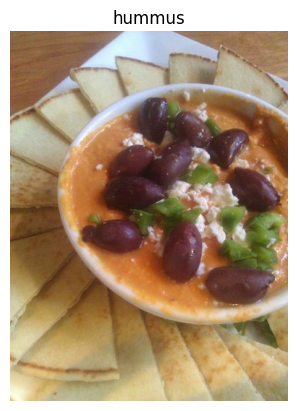

In [13]:
# Plot an image tensor
import matplotlib.pyplot as plt 
plt.imshow(image)
plt.title(class_names[label.numpy()]) # Add title to image to verify the label is associated with the right image 
plt.axis(False);

## Create preprocessing functions for our data

Neural networks perform best when data is in a certain way (e. g. batched, normalized, etc)

However, not all data (including data from TensorFlow datasets) comes like this.

So in order to get it ready for a neural network, you'll often have to write preprocessing functions and map it to your data.

What we know about our data:
* In `uint8` datatype
* Comprised of all different size tensors (different size images)
* Not scaled (the pixel values are between 0 & 255)

What we know models like:
* Data in `float32` dtype (or for mixed precision `float16` and `float32`)
* For batches, TensorFlow likes all of the tensors within a batch to be of the same size.
* Scaled (values between 0 & 1) also called normalized tensors generally perform better

With these points in mind, we've got a few things we can tackle with a preprocessing function.

Since we're going to be using an EfficientNetBX pretrained model from tf.keras.applicationss we don't need to rescale our data (these architecture have rescaling built-in).

This means our functions needs to :
1. Reshape our images to all the same size.
2. Convert the dtype of our image tensors from unit8 to float32

In [14]:
# Make a function for preprocessing images
def preprocess_img(image, label, img_shape=224):
    """
    Converts image datatype from 'unit8' -> 'float32' and reshapes image to [img_shape, colour_channells]
    """
    image = tf.image.resize(image, [img_shape, img_shape])
    return tf.cast(image, tf.float32), label

In [15]:
# Preprocess a single sample image and check the outputs
preprocessed_img = preprocess_img(image, label)[0]
print(f"Image before preprocessing:\n {image[:2]}..., \n Shape: {image.shape}, \nDatatype: {image.dtype} \n")
print(f"Image after preprocessing:\n{preprocessed_img[:2]}..., \nShape:{preprocessed_img.shape}, \nDatatype: {preprocessed_img.dtype}")

Image before preprocessing:
 [[[136 101  82]
  [138 103  84]
  [138 103  83]
  ...
  [154 118  94]
  [151 115  91]
  [149 113  87]]

 [[139 104  84]
  [141 106  86]
  [141 106  86]
  ...
  [151 115  89]
  [151 115  89]
  [152 117  89]]]..., 
 Shape: (512, 384, 3), 
Datatype: <dtype: 'uint8'> 

Image after preprocessing:
[[[138.64285  103.64286   84.      ]
  [139.78572  104.78571   84.64286 ]
  [137.92857  103.43367   79.918365]
  ...
  [152.64287  116.28572   95.357155]
  [152.16835  116.14284   91.168274]
  [150.95409  115.36735   88.79592 ]]

 [[129.21428   98.14285   70.448975]
  [132.35204  101.28571   72.55612 ]
  [133.07144  102.07143   73.14285 ]
  ...
  [159.15819  125.65817   94.76021 ]
  [161.63776  127.49492   93.071396]
  [162.40306  128.33163   92.40307 ]]]..., 
Shape:(224, 224, 3), 
Datatype: <dtype: 'float32'>
